# Placing a STARmap section in the Allen CCF

A 2D section fitted into a 3D reference volume, entirely through squidpy's public API:
`rasterize_points` -> `align_stalign_volume` -> `Stalign3DResult.transform` -> `sample_volume`.

## Inputs

Cells as a points element, the atlas and its annotation volume as 3D images. The physical
placement lives on the elements, so nothing downstream builds coordinate axes by hand.

In [1]:
import nrrd, numpy as np, pandas as pd, spatialdata as sd
from spatialdata.models import Image3DModel, PointsModel
from spatialdata.transformations import Scale, Sequence, Translation

cells = pd.read_csv('starmap_data/well11_spatial.csv.gz')
xy = np.c_[np.array(cells['X'])[1:], np.array(cells['Y'])[1:]].astype(float)

atlas, hdr = nrrd.read('ara_nissl_50.nrrd')       # (z, y, x)
labels, _ = nrrd.read('annotation_50.nrrd')       # same frame, integer structure ids
voxel = tuple(np.diag(hdr['space directions']))

def unit_range(a):
    """One linear map of the whole array onto [0, 1] -- both channels share the map."""
    return (a - a.min()) / np.ptp(a)

def reference_channels(volume):
    """Upstream's reference preprocessing: mean-normalised, and its own squared deviation.

    The second channel is not decoration. The solver regresses the deformed reference onto
    the section before measuring the match, so with one channel it fits a straight line
    `a + b*I` and with two it fits `a + b*I + c*(I - mean I)**2`. A regression absorbs a
    rescaling of its input; it cannot invent a channel it was never handed.
    """
    v = volume[None] / np.mean(np.abs(volume))
    return np.concatenate([v, (v - v.mean()) ** 2])

def centred(shape, spacing, axes):
    """The placement an atlas volume carries: voxel size, and the origin at its centre."""
    return Sequence([
        Scale(list(spacing), axes=axes),
        Translation(-(np.asarray(shape) - 1) * np.asarray(spacing) / 2, axes=axes),
    ])

sdata = sd.SpatialData(
    points={'cells': PointsModel.parse(xy)},
    images={'atlas': Image3DModel.parse(
        unit_range(reference_channels(atlas.astype(float))), dims=('c', 'z', 'y', 'x'),
        transformations={'global': centred(atlas.shape, voxel, ('z', 'y', 'x'))},
    )},
)
sdata

/localscratch/selman.ozleyen/stalign-nb-39766852/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SpatialData object
├── Images
│     └── 'atlas': DataArray[czyx] (2, 264, 160, 228)
└── Points
      └── 'cells': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        atlas (Images), cells (Points)

## The section

`rasterize_points` turns the centroids into a density image: each cell deposits unit mass
bilinearly, blurred once per scale, so total intensity is exactly the cell count.

In [2]:
from squidpy.experimental.im import rasterize_points, sample_volume

rasterize_points(sdata, 'cells', dx=50.0, blur=1.0, key_added='section')
sdata['section']

<xarray.DataArray 'image' (c: 1, y: 563, x: 760)> Size: 3MB
dask.array<array, shape=(1, 563, 760), dtype=float64, chunksize=(1, 563, 760), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 8B 0
  * y        (y) float64 5kB 0.5 1.5 2.5 3.5 4.5 ... 559.5 560.5 561.5 562.5
  * x        (x) float64 6kB 0.5 1.5 2.5 3.5 4.5 ... 756.5 757.5 758.5 759.5
Attributes:
    transform:  {'global': Sequence \n    Scale (y, x)\n        [50. 50.]\n  ...

### Putting both volumes on the scale the solver's parameters assume

`sigmaM`, `sigmaA`, `sigmaB`, `muA` and `muB` are in the **target's** intensity units, and
upstream states its values against a section that has been divided by its own mean and then
mapped onto `[0, 1]`. The reference gets the same treatment, which the solver's intensity
regression would absorb on its own -- but the second channel it is given alongside is not
something any regression can recover, so both steps are done here rather than assumed.

In [3]:
from spatialdata.models import Image2DModel
from spatialdata.transformations import get_transformation

def mean_normalised(sdata, key):
    """Rescale an image element by its own mean intensity, keeping its placement."""
    element = sdata.images[key]
    values = np.asarray(element)
    sdata.images[key] = Image2DModel.parse(
        values / np.abs(values).mean(), dims=('c', 'y', 'x'),
        transformations={'global': get_transformation(element, 'global')},
    )

mean_normalised(sdata, 'section')
element = sdata.images['section']
sdata.images['section'] = Image2DModel.parse(
    unit_range(np.asarray(element)), dims=('c', 'y', 'x'),
    transformations={'global': get_transformation(element, 'global')},
)
section = np.asarray(sdata['section']).squeeze()
print(f'section now spans {section.min():.2f} to {section.max():.2f}, mean {section.mean():.2f}')

section now spans 0.00 to 1.00, mean 0.10


## The fit

`initial_slice`, `initial_rotation` and `initial_scale` are an initialisation, not the answer --
the full 3D deformation is fitted, so the section need not be exactly coronal.

In [4]:
from squidpy.experimental.tl import align_stalign_volume

def physical_axes(element, axes):
    """Physical coordinate vector per axis, in array order.

    An element's `.coords` are pixel indices (0.5, 1.5, ...), not physical units -- the
    placement lives in the element's transformation. Reading `.coords` directly and treating
    it as microns silently replaces 425 um of depth with 140, which is a fit that starts in
    the wrong place and never recovers.
    """
    matrix = get_transformation(element, 'global').to_affine_matrix(input_axes=axes, output_axes=axes)
    return [(np.asarray(element.coords[a]) - 0.5) * matrix[k, k] + matrix[k, -1]
            for k, a in enumerate(axes)]

# `initial_scale` is one uniform factor for all three axes, and this dataset is anisotropic:
# ~4x in plane, ~0.9x through the slice axis. `initial_affine` is the escape hatch.
#
# Built in the solver's (z, y, x) and reversed once at the end. Composing it directly in
# (x, y, z) means hand-transposing a rotation, two scales and three translations, and each is
# a chance to mirror an axis silently -- so the reversal gets exactly one line.
theta, scale_xy, scale_z, slice_index = np.pi / 2, 4.0, 0.9, 140
z_axis, _, _ = physical_axes(sdata['atlas'], ('z', 'y', 'x'))
y_axis, x_axis = physical_axes(sdata['section'], ('y', 'x'))

# The one landmark this analysis pins: atlas (0, 0) sits at (-3700, 0) in the section, in (-y, -x).
landmark_yx = np.array([-3700.0, 0.0])

rotation = np.array([[1.0, 0.0, 0.0],
                     [0.0, np.cos(theta), -np.sin(theta)],
                     [0.0, np.sin(theta), np.cos(theta)]])
affine_zyx = np.eye(4)
affine_zyx[:3, :3] = rotation @ np.diag([scale_z, scale_xy, scale_xy])
affine_zyx[:3, 3] = [-z_axis[slice_index],
                     y_axis.mean() - landmark_yx[0] * scale_xy,
                     x_axis.mean() - landmark_yx[1] * scale_xy]

reverse = np.eye(4)[[2, 1, 0, 3]]          # spatial axes only; the homogeneous row stays put
initial_affine = reverse @ affine_zyx @ reverse

# `sigmaR` is deliberately absent. Upstream's `LDDMM_3D_to_slice` declares 1e8, which weights
# the regulariser so weakly that the velocity field grows unchecked; squidpy's volume default
# is the retuned 1e6, and letting the default supply it is the point.
SOLVER = dict(a=250.0, nt=4, sigmaM=0.1, sigmaA=0.1, sigmaB=0.1, muA=[0.7], muB=[0.0])

### Is the initialisation in the right place?

`niter=0` returns the starting affine without fitting, so the initial guess can be looked at
through the same public route as the result. Worth doing: an initialisation that starts in the
wrong place produces a fit that never recovers, and the objective alone does not say so.

In [5]:
guess = align_stalign_volume(
    sdata, image_key=('atlas', 'section'), initial_affine=initial_affine, niter=0, **SOLVER
)

def atlas_at(result):
    """The atlas resampled onto the section's plane, through a fit's own backward map."""
    plane = np.moveaxis(np.asarray(result.deformation_grid(direction='backward')), 0, -1)[0]
    sampled = sample_volume(atlas, result.ref_axes, plane.reshape(-1, 3)[:, ::-1])
    return sampled.reshape(plane.shape[:2])

initial_depth = np.asarray(guess.transform(xy))[:, 2]
print(f'initial guess places the section at z = {initial_depth.mean():.0f} um '
      f'(slice {slice_index} sits at {z_axis[slice_index]:.0f} um)')

initial guess places the section at z = 472 um (slice 140 sits at 425 um)


In [6]:
fit = align_stalign_volume(
    sdata, image_key=('atlas', 'section'), initial_affine=initial_affine, niter=800, **SOLVER
)
print(f'{fit.n_iter} iterations, objective '
      f'{float(fit.energies[0]):.0f} -> {float(fit.energies[-1]):.0f}')

800 iterations, objective 92837 -> 94231


The objective is not one function across this whole trace. The mixture E step switches on at
iteration 50 (`STalign.py:1233`): before it, the artifact / background / matching weights are
frozen at their initial values, so the energy either side of the dashed line is computed
against different weights and steps discontinuously there. Squidpy's own solver says so --
"the objective changes definition here and its value jumps discontinuously".

So the descent worth reading is the part after the gate. A minimum reported "at iteration 49"
belongs to the pre-gate objective, not to a better alignment, and stopping there would stop
before the mixture model has done anything at all. `tol` already knows this: its warm-up runs
to `50 + 2 + patience` before the improvement test is allowed to fire.

What a flat post-gate tail means here is that the affine and the velocity field have settled;
the panels below are the check that matters, and they are the reason this is read as converged
rather than as a fit that ran away.

after the gate: 101781 -> 94231, minimum 79348 at iteration 626
last tenth: mean 88791, spread 30380 (34.2% of its mean)


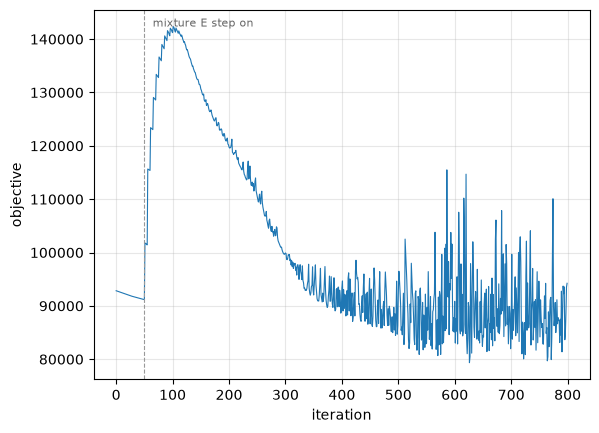

In [7]:
import matplotlib.pyplot as plt

# Upstream's gate, not a tuning knob: `STalign.py:1233` starts the mixture E step at 50.
MIXTURE_GATE = 50

energies = np.asarray(fit.energies)[: fit.n_iter]
descent = energies[MIXTURE_GATE + 1 :]        # the half of the trace that shares a definition
tail = descent[-len(descent) // 10 :]
print(f'after the gate: {descent[0]:.0f} -> {descent[-1]:.0f}, minimum {descent.min():.0f} '
      f'at iteration {MIXTURE_GATE + 1 + int(descent.argmin())}')
print(f'last tenth: mean {tail.mean():.0f}, spread {np.ptp(tail):.0f} '
      f'({100 * np.ptp(tail) / tail.mean():.1f}% of its mean)')

plt.plot(energies, lw=0.8)
plt.axvline(MIXTURE_GATE, color='0.6', lw=0.8, ls='--')
plt.annotate('mixture E step on', (MIXTURE_GATE, plt.ylim()[1]), fontsize=8,
             xytext=(6, -12), textcoords='offset points', color='0.4')
plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=0.3)

## Where each cell lands

`transform` maps `(x, y)` section coordinates to `(x, y, z)` reference coordinates, evaluated at
each point rather than at the nearest raster cell. `sample_volume` then reads the annotation
volume there -- `order=0` because structure ids must not be interpolated.

In [8]:
coords = np.asarray(fit.transform(xy))                 # (N, 3), (x, y, z) in microns
structure_id = sample_volume(labels, fit.ref_axes, coords, order=0).astype(int)

print(f'{len(coords)} cells placed, {np.unique(structure_id).size} distinct structures, '
      f'{100 * (structure_id == 0).mean():.1f}% outside any annotated structure')
print(f'depth (z) spans {coords[:, 2].min():.0f} to {coords[:, 2].max():.0f} um')

43341 cells placed, 165 distinct structures, 2.4% outside any annotated structure
depth (z) spans 411 to 659 um


Structure ids become acronyms through the Allen ontology.

In [9]:
ontology = pd.read_csv('allen_ontology.csv').set_index('id')['acronym']
acronym = pd.Series(structure_id).map(ontology).fillna('unassigned')
acronym.value_counts().head(12)

CP            1567
MEA           1434
CA1           1405
VPM           1269
PIR           1248
DG-sg         1209
unassigned    1034
or             854
HY             833
SSp-bfd2/3     745
LHA            731
SSp-bfd4       709
Name: count, dtype: int64

## The aligned atlas over the section

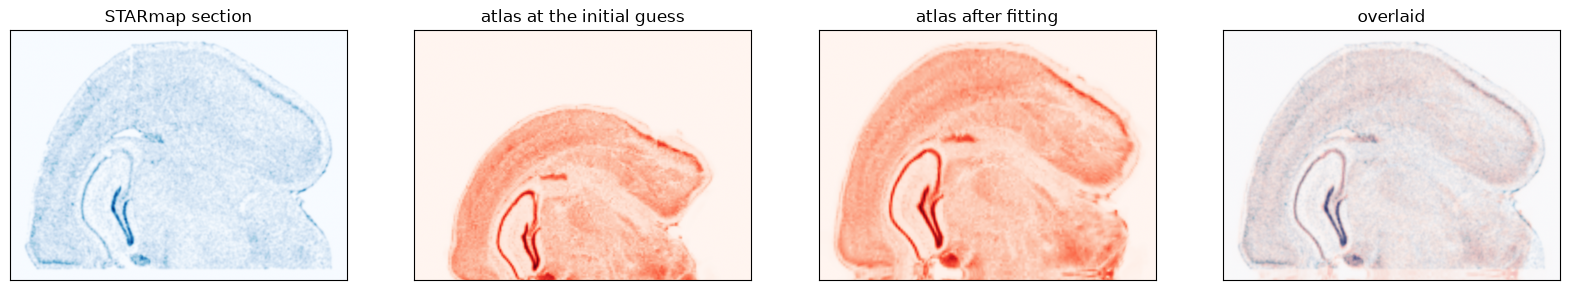

In [10]:
import matplotlib as mpl

section = np.asarray(sdata['section']).squeeze()
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(section, cmap=mpl.cm.Blues)
ax[1].imshow(atlas_at(guess), cmap=mpl.cm.Reds)
ax[2].imshow(atlas_at(fit), cmap=mpl.cm.Reds)
ax[3].imshow(section, cmap=mpl.cm.Blues, alpha=0.9)
ax[3].imshow(atlas_at(fit), cmap=mpl.cm.Reds, alpha=0.3)
for a, t in zip(ax, ('STARmap section', 'atlas at the initial guess',
                     'atlas after fitting', 'overlaid'), strict=True):
    a.set_title(t); a.set_xticks([]); a.set_yticks([])

## Cells coloured by structure

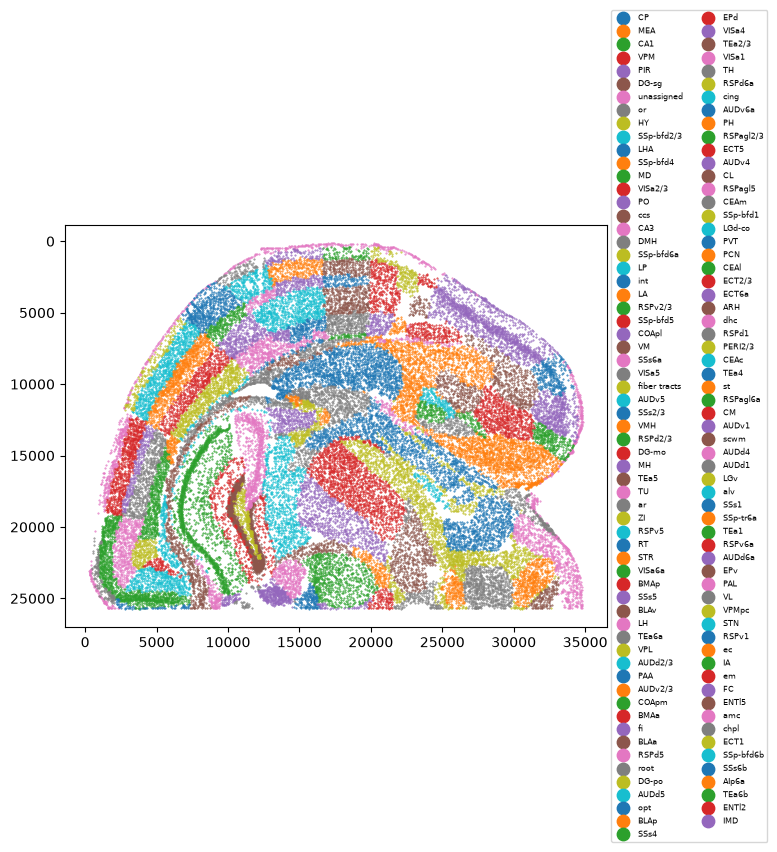

In [11]:
keep = acronym.value_counts()
keep = keep[keep >= 50].index                       # a legend of singletons reads as noise
fig, ax = plt.subplots(figsize=(7, 6))
for region in keep:
    m = (acronym == region).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=0.2, label=region)
ax.invert_yaxis(); ax.set_aspect('equal')
ax.legend(markerscale=20, fontsize=6, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))